# Naive Bayes i Classificació


En aquest tercer lliurament es programarà un classificador, que donada una *piulada*, la categoritzarà en una de les possibles classes. En aquesta ocasió, implementareu un classificador amb *piulades* relacionades amb el *cyber bullying*.

Recordeu que l'objectiu principal d'aquesta pràctica és desenvolupar un classificador amb una *accuracy* alta. 


**Què s’ha de fer?**

Volem classificar *piulades* segons a quin tipus de *cyber bullying* pertanyen. Així doncs, a partir de tots les *piulades* que tenim, crearem un vector de característiques que ens descrigui cadascuna. A continuació desenvoluparem un classificador probabilístic del tipus **Naive Bayes** que ens permeti identificar a quina classe de *cyber bullying* pertany una *piulada* donada, segons les característiques disenyades.


**Quina és la idea del sistema de classificació que s’ha de desenvolupar?**

El classificador és un concepte de l'aprenentatge automàtic supervisat. L'objectiu del classificador és donat un vector de característiques que descriuen els objectes que es volen classificar indicar a quina categoria o classe pertanyen d'entre un conjunt predeterminat. 

El procés de classificació consta de dues parts: 

+ el procés d'aprenentatge i 
+ el procés d'explotació o testeig. 

El procés d'aprenentatge rep exemples de parelles $(x,y)$ on $x$ són les característiques, usualment representades per nombres reals, i $y$ és la categoria a la que pertanyen. 
Aquest conjunt se'l coneix com a conjunt d'entrenament i ens servirà per trobar una funció $\hat{y}=f(x)$ que donada una $x$ aconsegueixi que $\hat{y}$ sigui semblant $y$. 

Per altra banda el procés de testeig aplica la funció $f(x)$ apresa a l'entrenament a a dades no presents en el conjunt d'aprenentatge per avaluar el classificador.

**Classificació i llenguatge natural**

La descripció dels exemples en característiques és el punt més crític de tot sistema d'aprenentatge automàtic. 
Una de les representacions més simples per tal de descriure un text és la representació ["bag-of-words"](https://en.wikipedia.org/wiki/Bag-of-words_model).

Aquesta representació converteix un text en un vector de $N$ paraules. 
Primer haurem de seleccionar el conjunt d'$N$ paraules que volem fer servir. Després, per cada paraula comptar quants cops apareix en el text. 

Una versió alternativa i més simple d'aquest procés pot ser simplement indicar al vector si una determinada paraula apareix o no en el text.

## Abans de començar


**\+ Durant la pràctica, solament es podran fer servir les següents llibreries**:

`Pandas, Numpy, Re` i `NLTK`

Python té un paquet integrat anomenat ["re"](https://www.w3schools.com/python/python_regex.asp), que es pot utilitzar per treballar amb expressions regulars. És molt aconsellable fer servir aquest paquet per processar les paraules.

**\+ No es poden modificar les definicions de les funcions donades, ni canviar els noms de les variables i paràmetres ja donats**

Això no implica però que els hàgiu de fer servir. És a dir, que la funció tingui un paràmetre anomenat `df` no implica que l'hàgiu de fer servir, si no ho trobeu convenient.

**\+ En les funcions, s'especifica que serà i de quin tipus cada un dels paràmetres, cal respectar-ho**

Per exemple (ho posarà en el pydoc de la funció), `df` sempre serà indicatiu del `Pandas.DataFrame` de les dades. Durant els testos, els paràmetres (i específicament `df`) no contindran les mateixes dades que en aquest notebook, si bé si seran del mateix tipus! Per tant, no us refieu de què tinguin, per exemple, el mateix nombre de files.

## Les dades

El 15 d'Abril de 2020, UNICEF va llançar una alarma com a resposta de l'augment de risc de *cyber bullying* durant la pandèmia COVID-19. 

Les estadístiques són prou alarmants: un 36.5% dels estudiants de l'escola fins a l'institut s'han sentit víctimes del *cyber bullying* i un 87% n'han estat testimonis, amb efectes que van des d'una disminució de resultats acadèmics fins a pensaments suïcides.

Amb l'objectiu d'ajudar a l'analisis de la situació, s'ha construit un dataset que conté més de 47000 *piulades* etiquetades d'acord amb la classe de *cyber bullying* que s'està donant:

1. `age`;
2. `ethnicity`;
3. `gender`;
4. `religion`;
5. `other type of cyberbullying`;
6. `not cyberbullying`

Les dades han estat balancejades per tal de contenir aproximadament 8000 mostres de cada classe.

# Preparar les dades

## Lectura de les dades

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

In [2]:
df = pd.read_csv('./cyberbullying_tweets.csv')
df

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


In [3]:
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

## Preparació del dataset

Dividim les *piulades* en un conjunt d'entrenament, *train*, i en un conjunt de validació, *test*, per tal de poder entrenar i validar el nostre model de classificació.

In [4]:
from sklearn.model_selection import train_test_split

df_tweets_train, df_tweets_test = train_test_split(df, test_size=0.2)

Com les dades estaven balancejades originalment, podem observar que la distribució de cadascuna de les classes es manté:

In [5]:
df_tweets_train['cyberbullying_type'].value_counts()

cyberbullying_type
age                    6434
gender                 6430
religion               6423
not_cyberbullying      6327
ethnicity              6303
other_cyberbullying    6236
Name: count, dtype: int64

In [6]:
df_tweets_test['cyberbullying_type'].value_counts()

cyberbullying_type
ethnicity              1658
not_cyberbullying      1618
other_cyberbullying    1587
religion               1575
age                    1558
gender                 1543
Name: count, dtype: int64

# Implementació

Dividirem el notebook en 3 seccions que es complementen una a l'altra:

1. Anàlisi exploratòria de les dades: Informació bàsica sobre les *piulades*.
2. Processament de les dades: Creació d'un vector de característiques a partir de les *piulades*.
3. Desenvolupament d'un classificador *Naive Bayes*. 

### 1. Anàlisis de dades

El primer que haurem de fer és analitzar les dades per veure una mica com són. El que us proposem és fer una sèrie de visualitzacions per observar les dades, com ara:

* el nombre de *piulades* que s'estan dirigint a una persona en concret
* el nombre de  *hashtags* que hi ha a cada categoria de *piulades*
* el nombre de  *piulades* que hi ha de cada categoria de *piulades*
* el nombre de  *piulades* de la categoria `not_cyberbullying` que es dirigeixen a un usuari vs totes les altres categories
* altres coses que penseu que poden ser rellevants.

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
df_tweets_train

,tweet_text,cyberbullying_type
6297,Gostei do clipe novo da Jessie J. Trata do bul...,not_cyberbullying
8121,"Suck shit Kat you vile, venomous, nasty bitch!...",gender
14934,RT @proglegs @OrbitzGayTravel Why is @Orbitz a...,gender
24986,Dismay over Liam Fox's claim of 'shared values...,other_cyberbullying
116,Lolol that boy is whipped AF,not_cyberbullying
...,...,...
29937,RT @punched93: HAPPENING NOW: getting my butth...,other_cyberbullying
29187,@celiadeeter THAT WAS AMAZING. I LOVE YOU ❤️❤️❤️,other_cyberbullying
28846,RT @Hollapalooka: Checked the #gdc2015 tag w/ ...,other_cyberbullying
20522,shut down @ZeeNews and put these idiots behind...,religion


#### EXERCICI 1: 

* Quantes *piulades* estan dirigides a un usuari concret? Diem que una piulada va dirigida a una persona en concret si contenen el patró ``@usuari``. 

[Restriccions](https://help.twitter.com/en/managing-your-account/change-twitter-handle) que imposa X sobre el patró:
+ Nomes són valids aquells patrons amb caràcters alfanumèrics ``[A-z 0-9]`` i el caràcter ``_``
+ Els patrons han de començar per ``@`` i han de tenir més de 4 i menys de 16 caràcters.

En aquest exercici és extremadament útil l'ús del mòdul ``re``.

In [9]:
reg = r'@(?=[A-Za-z0-9_])(?:\w{5,15})'
string_tweets = df['tweet_text'].to_json()

# Find all unique matches
usernames = set(re.findall(reg, string_tweets))

print("Number of mentioned usernames in offensive Tweets:", len(usernames))

Number of mentioned usernames in offensive Tweets: 13416


In [10]:
# Alternative using DataFrames, which yields a different result
mentions = df[df['tweet_text'].str.contains(reg, regex=True)]
print(mentions.shape[0])

17901


+ Quants *hashtags* ``#`` hi ha a cada categoria de *piulades*?

Compteu els ``#`` que vagin seguits d'alguna lletra o nombre ja que, com veiem a la [normativa](https://help.twitter.com/en/using-twitter/how-to-use-hashtags) de X, els ``#`` no poden contenir cap mena de signe de puntuació.

In [11]:
reg = r'#(?=[A-Za-z0-9])(?:\w+)'

# Work in a copy, just in case
data = df.copy()

# Count hashtags per row
data['valid_hashtags'] = data['tweet_text'].str.findall(reg)
data['valid_hashtags_count'] = data['valid_hashtags'].apply(len)

# Total hashtag count across all rows
total_hashtags = data['valid_hashtags_count'].sum()

In [12]:
display(data)

,tweet_text,cyberbullying_type,valid_hashtags,valid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,"[#katandandre, #mkr]",2
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,[],0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,[],0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,[],0
...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,[],0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,[],0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,[],0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,[],0


In [13]:
hcount = data.groupby("cyberbullying_type")['valid_hashtags_count'].sum()
display(hcount)

cyberbullying_type
age                     728
ethnicity              1112
gender                 2691
not_cyberbullying      3265
other_cyberbullying    1625
religion               1798
Name: valid_hashtags_count, dtype: int64

+ Fes un histograma que representi aquesta distribució?

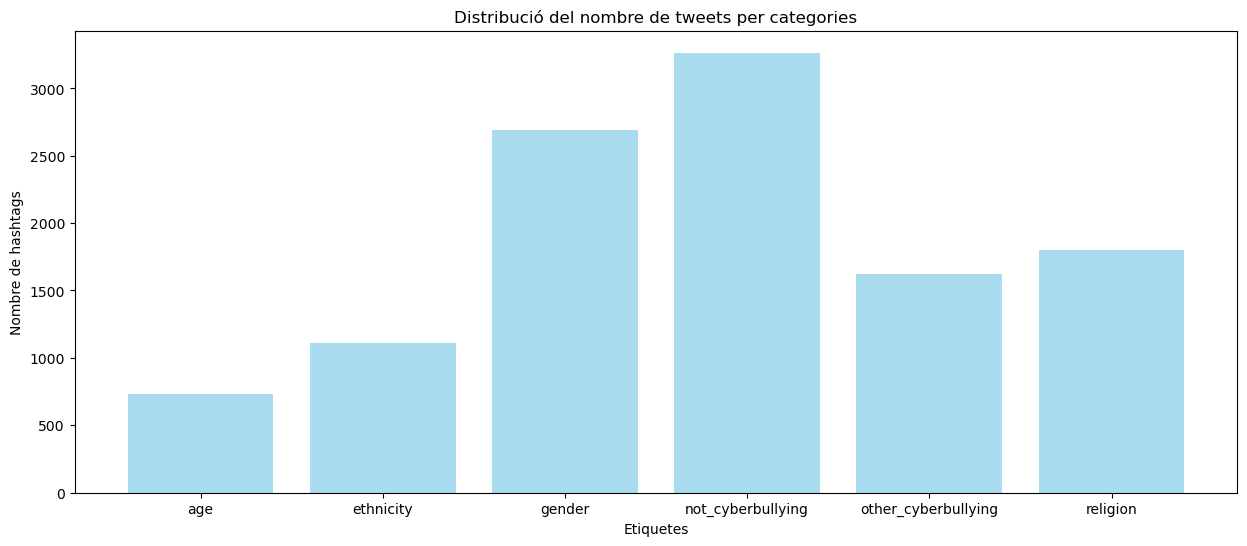

In [14]:
plt.figure(figsize=(15,6))
plt.bar(hcount.index, hcount.values, color='skyblue', alpha=0.7)

# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Etiquetes")
plt.ylabel("Nombre de hashtags")
plt.title("Distribució del nombre de tweets per categories")
# Mostrem el temps a l'eix x
plt.xticks(hcount.index)
plt.show()

+ Comproveu a continuació quantes vegades hi ha un ús invàlid dels ``#``, per exemple ``##`` o ``#@``, on, si no tinguessim en compte la restriccio imposada, hauriem contat 2 ``#`` a ``##`` o 1 ``#`` a ``#@``, quan en realitat son 1 i 0 respectivament.

In [15]:
# Sobre el total de hashtags, agafem el complementari del valid_hashtags
# Count hashtags per row
data['total_hashtags_count'] = data['tweet_text'].str.findall("#").apply(len)
# Invalid hashtag count
data['invalid_hashtags_count'] = data['total_hashtags_count'] - data['valid_hashtags_count']
display(data)

,tweet_text,cyberbullying_type,valid_hashtags,valid_hashtags_count,total_hashtags_count,invalid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,"[#katandandre, #mkr]",2,2,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10,10,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,[],0,0,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,[],0,0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,[],0,0,0
...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,[],0,0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,[],0,0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,[],0,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,[],0,0,0


In [16]:
print(data['invalid_hashtags_count'].sum())

102


+ Quantes *piulades* vàlides hi ha de cada categoria?

In [17]:
# Valid tweet is not mention-invalid and not hashtag-invalid
reg = r'@[^A-Za-z0-9_]'
invalid_mentions = data[data['tweet_text'].str.contains(reg, regex=True)].index
invalid_hashtags = data[data['invalid_hashtags_count'] > 0].index

In [18]:
invalid_tweets = invalid_mentions.union(invalid_hashtags)
valid_tweets = data.drop(invalid_tweets, axis=0)
display(valid_tweets.groupby("cyberbullying_type").size())

cyberbullying_type
age                    7980
ethnicity              7951
gender                 7926
not_cyberbullying      7912
other_cyberbullying    7791
religion               7984
dtype: int64

+ Quantes *piulades* de la categoria `not_cyberbullying` és dirigeixen a un usuari?
+ Quantes *piulades* de totes les altres categories és dirigeixen a un usuari?

In [19]:
reg = r'@(?=[A-Za-z0-9_])(?:\w{5,15})'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]
# We will try to delete some invalid mentions that will not appear, so we ignore errors
valid_mentions = mentions.drop(invalid_tweets, axis=0, errors='ignore') 
display(valid_mentions.groupby("cyberbullying_type").size())

cyberbullying_type
age                     326
ethnicity              3333
gender                 3176
not_cyberbullying      4094
other_cyberbullying    4732
religion               2177
dtype: int64

+ Calculeu altres coses que penseu que poden ser rellevants (usuaris més mencionats, *hashtags* més comuns per cada categoria, etc.).

In [20]:
# It detects all ocurrences of a sequence separately
test = "@hola @hola @adeu @hello @hello @byebye"
re.findall(r"@(?:\w+)", test)

['@hola', '@hola', '@adeu', '@hello', '@hello', '@byebye']

In [21]:
data['valid_mentions'] = data['tweet_text'].str.findall(reg)
data['valid_mentions_count'] = data['valid_mentions'].apply(len)
data['total_mentions_count'] = data['tweet_text'].str.findall(r"@").apply(len)
data['invalid_mentions_count'] = data['total_mentions_count'] - data['valid_mentions_count']
display(data)

,tweet_text,cyberbullying_type,valid_hashtags,valid_hashtags_count,total_hashtags_count,invalid_hashtags_count,valid_mentions,valid_mentions_count,total_mentions_count,invalid_mentions_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,"[#katandandre, #mkr]",2,2,0,[],0,0,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10,10,0,[],0,0,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,[],0,0,0,[@XochitlSuckkks],1,1,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,[],0,0,0,[@Jason_Gio],1,1,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,[],0,0,0,[@RudhoeEnglish],1,1,0
...,...,...,...,...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,[],0,0,0,[],0,0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,[],0,0,0,[],0,0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,[],0,0,0,[],0,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,[],0,0,0,[@therealexel],1,1,0


In [22]:
used_hashtags = data.explode("valid_hashtags").groupby("valid_hashtags").size()
used_hashtags = used_hashtags.sort_values(ascending=False)
display(used_hashtags)

valid_hashtags
#MKR                      1319
#mkr                      1192
#Islam                     145
#BlameOneNotAll            117
#notsexist                 105
                          ... 
#10YearsOfOneDirection       1
#10ThousandStepsAgain        1
#10SecondHeadLoss            1
#10ReasonsToFollowMe         1
#10PeopleYouTrulyLove        1
Length: 4962, dtype: int64

My Kitchen Rules (often abbreviated as MKR) is an Australian competitive cooking game show broadcast on the Seven Network since 2010. The show is currently hosted and judged by chefs Manu Feildel and Colin Fassnidge, with Feildel being the only judge who has appeared in every season of the show.

In [23]:
# Alternative that uses pandas
used_hashtags = data.explode("valid_hashtags")
used_hashtags = used_hashtags.pivot_table(index='valid_hashtags', columns='cyberbullying_type', aggfunc='size', fill_value=0)
used_hashtags['total'] = used_hashtags.sum(axis=1)

In [24]:
# 15 more used hashtags, and now by category
used_hashtags.sort_values(by='total', ascending=False)[:15]

cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion,total
valid_hashtags,,,,,,,
#MKR,0,2,312,821,182,2,1319
#mkr,0,0,319,770,103,0,1192
#Islam,0,0,2,19,0,124,145
#BlameOneNotAll,0,1,16,0,100,0,117
#notsexist,0,0,103,2,0,0,105
#ISIS,0,1,0,36,3,54,94
#MKR2015,0,0,25,43,17,0,85
#coon,0,19,2,0,54,0,75
#MileyCyrus,0,0,68,0,0,0,68


In [25]:
# Take the first idea for hashtags and use it for users
used_mentions = data.explode("valid_mentions").groupby("valid_mentions").size()
used_mentions = used_mentions.sort_values(ascending=False)
display(used_mentions)

valid_mentions
@tayyoung_         958
@freebsdgirl       233
@MaxBlumenthal     161
@mykitchenrules    115
@ChrisWarcraft     104
                  ... 
@zzoegrimm           1
@10to8_Mr_Glass      1
@zemichi             1
@zene55              1
@1959greenarrow      1
Length: 13419, dtype: int64

In [26]:
# We can even use the second idea for hashtags to see mentions by category of cyberbullying
used_mentions = data.explode("valid_mentions")
used_mentions = used_mentions.pivot_table(index='valid_mentions', columns='cyberbullying_type', aggfunc='size', fill_value=0)
used_mentions['total'] = used_mentions.sum(axis=1)
used_mentions.sort_values(by='total', ascending=False)[:15]

cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion,total
valid_mentions,,,,,,,
@tayyoung_,0,958,0,0,0,0,958
@freebsdgirl,0,0,7,75,151,0,233
@MaxBlumenthal,0,0,1,41,0,119,161
@mykitchenrules,0,0,30,67,18,0,115
@ChrisWarcraft,0,0,12,23,69,0,104
@MT8_9,0,0,89,7,5,0,101
@TheQuinnspiracy,0,0,0,25,76,0,101
@IsraeliRegime,0,0,0,17,0,82,99
@Spacekatgal,0,0,1,34,63,0,98


In [27]:
# As we can see, @tayyoung_ and his/her network are pretty disrespectful individuals
reg = r'@tayyoung_'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]
display(mentions['tweet_text'])

39732    Fuck u bitch RT @tayyoung_: FUCK OBAMA, dumb a...
39748    @D_Paid: @Twin_Thing_Two: Y'all see this thoug...
39750    You a racist ass bitch and dat same dumb ass n...
39767    @tayyoung_: FUCK OBAMA, dumb ass nigger You ma...
39771    FUCK YOU BITCH!! he got 4 more yrs, get used t...
                               ...                        
47660    “@tayyoung_: FUCK OBAMA, dumb ass nigger”&lt;&...
47661    fuck you fat white bitch. RT @tayyoung_: FUCK ...
47663    You ain't get no Dick tonight so you mad at th...
47670    RT @Mr200taxnjckson: Taylor on a scale from cr...
47672    A Harvard JD doesn't imply "dumb" RT @StaxxFif...
Name: tweet_text, Length: 957, dtype: object

In [28]:
# Honorable mention to the 95 mentions of Donald Trump
reg = r'@realDonaldTrump'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]
display(mentions['tweet_text'])

13718    I have to quit being tactful @SenatorBraun @Se...
14195    Ridiculousness. I did not hear her click conde...
14744    Anyone else hear the female reporter call Kayl...
16221    Buhari should be in prison @POTUS @realDonaldT...
16450    I’ve got breaking news for you. If you support...
                               ...                        
45196    The “other “ “you don’t look like u belong” #A...
45487    @realDonaldTrump YO DUMB FUCK! STOP YOUR BULLS...
46286    Instead of using Twitter to extend condolences...
46555    Is my dad a brainwashed republican; yes! Does ...
47298    #NancyPelosiROCKS @MSNBC @CNNPolitics She stoo...
Name: tweet_text, Length: 95, dtype: object

### 2. Comptar paraules

In [29]:
# No modificar aquesta cel·la, s'encarrega de fer el procés més eficient.
# Intenteu entendre quà fa aquesta cel·la

def memo(f):
    class memodict(dict):
        def __init__(self, f):
            self.f = f
        def __call__(self, *args):
            return self[args]
        def __missing__(self, key):
            ret = self[key] = self.f(*key)
            return ret
    return memodict(f)

El primer que haurem d'implementar és la funció ``standardize`` que estandaritzarà les paraules.

#### EXERCICI 2: 

+ Empleneu la funció següent que, donada una paraula, la estandaritzi les paraules passant tots els caràcters a minúscules.

**Observació:** Podeu considerar diverses possibilitats per aquesta funció:
* Només canviar les lletres majúscules per minúscules
* Eliminar tots els símbols que no siguin @, # i _ (i substituïr-los per un espai)
* Eliminar tots els símbols (i substituïr-los per un espai)
* etc.

El mòdul `re` de Python és especialment útil en aquest punt. 

Trieu aquella possibilitat que dóna millor resultats a l'exercici 7!

In [30]:
def standardize(word):
    """
    :param word: paraula a estandaritzar
    :return : paraula estandaritzada
    """
    word = word.lower()
    word = re.sub(r'[^a-z0-9@#_ ]', "", word)
    word = re.sub(r'\s+', " ", word).strip()
    return word

In [31]:
standardize("Taller DELS noUS USOS")

'taller dels nous usos'

In [32]:
standardize("Taller DELS noUS USOS#!!!!! @hola???")

'taller dels nous usos# @hola'

#### EXERCICI 3: 

+ Feu una funció ``count_words`` que construeixi un diccionari que contingui totes les paraules que s'han trobat al dataset, tot indicant el total de cops que ha aparegut cadascuna i el nombre de piulades on apareix. 

El resultat ha de ser un diccionari d'aquest tipus (no necessàriament amb aquest valors):

```python
{
    'memory' : {'n_ocur': 88, 'n_piu': 76},
    'best': {'n_ocur': 123, 'n_piu': 65},
    ...
}
```

In [33]:
def count_words(df):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {word : {n_ocur: valor, n_tweets: valor}, ...}
    """
    # Step 1: We are interested in the text
    data = df['tweet_text'].apply(standardize)
    words = data.str.split()

    # Step 2: Initialize the word counter
    word_stats = {}

    # Step 3: Count word occurrences and appearances
    for w in words:
        unique_words = set(w)  # Unique words in the current tweet
        for word in w:
            if word not in word_stats:
                word_stats[word] = {'n_ocur': 0, 'n_piu': 0}
            word_stats[word]['n_ocur'] += 1
        for word in unique_words:
            word_stats[word]['n_piu'] += 1

    return word_stats

In [34]:
dicc_text = count_words(df_tweets_train)
print (len(dicc_text))
print("'rape':",dicc_text['rape']) # ens hauria de donar n_ocur=3332, n_piu=3098

58670
'rape': {'n_ocur': 3397, 'n_piu': 3147}


### 3. Comptar paraules per cada categoria de piulada

In [35]:
df_tweets_train.head()

,tweet_text,cyberbullying_type
6297,Gostei do clipe novo da Jessie J. Trata do bul...,not_cyberbullying
8121,"Suck shit Kat you vile, venomous, nasty bitch!...",gender
14934,RT @proglegs @OrbitzGayTravel Why is @Orbitz a...,gender
24986,Dismay over Liam Fox's claim of 'shared values...,other_cyberbullying
116,Lolol that boy is whipped AF,not_cyberbullying


#### EXERCICI 4: 

+ Fent servir la funció que se us dona a continuació (`eachTopic`), apliqueu-la per tal de comptar les paraules que s'han trobat i la seva ocurrència segregant ara per categoria.

El resultat ha de ser un diccionari d'aquest tipus (no necessàriament amb aquest valors):

```python
{
    'ethnicity': {
        'race' : {'n_ocur': 88, 'n_piu': 76},
        'what': {'n_ocur': 123, 'n_piu': 65}
        ...
    },
    ...
    'gender': {
        'jokes' : {'n_ocur': 18, 'n_piu': 17},
        'you': {'n_ocur': 154, 'n_piu': 66}
    }
    ...
}
```

In [36]:
def count_words_categories(df):
    """
    Funció que ha de constuir un diccionari que conté la freqüència de les 
    paraules i el número de piulades on ha aparegut. 
    Aquesta informació ha de ser dividida per diferents categories de cyberbullying.
    
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {label : {word : {n_ocur: valor, n_news: valor} } }
    """
    words_topic = dict()
        
    def eachTopic(group):
        # Count words in this topic and save to the dictionary
        category = group['cyberbullying_type'].iloc[0]
        words_topic[category] = count_words(group)
        
    # Group the DataFrame by 'cyberbullying_type' and apply eachTopic function
    #data = df.groupby('cyberbullying_type').apply(eachTopic)
    #display(data)
    #return words_topic
    categories = df["cyberbullying_type"].unique()
    for category in categories:
        data = df[df["cyberbullying_type"] == category]
        eachTopic(data)
    return words_topic

In [37]:
words_categories = count_words_categories(df_tweets_train)
print ("Categories:", len(words_categories))
print ("La paraula 'muslims' a la categoria 'religion':", words_categories["religion"]['muslims'])

Categories: 6
La paraula 'muslims' a la categoria 'religion': {'n_ocur': 1906, 'n_piu': 1680}


### 4. Paraules més freqüents a les piulades


**El problema de com escollir el vector de carecterístiques**

L'elecció de les paraules que formen el vector de característiques és un pas crític. En funció de com de bona sigui aquesta descripció, millor funcionarà el sistema. Tot i que us deixem a vosaltres la política de creació del vector de característiques us donem una pista: una possible estratègia és agafar aquelles paraules que apareixen entre en un 10 i un 50 percent del total de piludades (sense tenir en compte la categoria). És a dir, paraules que no són ni massa freqüents ni massa poc. Podeu experimentar variant aquests valors.

Una altra estratègia interessant és eliminar "stop words".

#### EXERCICI 5: 

+ Feu una funció ``topNwords`` que crei un diccionari amb les N paraules més representatives (les que apareixen amb més freqüència) de cadascuna de les categories de *cyberbullying* (Tenint en compte que haureu tret aquelles paraules que apareixen en la majoria de piulades, així com també, les que únicament apareixen en un conjunt molt petit de piulades). Una pista de que aneu ben encaminats es que per cadascuna de les categories de *cyberbullying* obtingueu paraules rellevants per aquesta. Si no es així, vol dir que heu d'incrementar el nombre de paraules a saltar (*skip_top*).

El resultat serà un diccionari tipus (no necessàriament amb aquest valors):

```python
{
    'age': ['school', 'high', ...],
    ...
    'religion': ['muslims', 'christian',...]
    ...
}
```

+ Experimenteu omplint la llista `skip_top` amb aquelles paraules que penseu no tenen significat o relevancia per definir cada categoria. Podeu buscar informació sobre **stop words** a internet i definir varies llistes fins que penseu que obteniu una bona representació de paraules per categoria de `cyberbullying`.

In [38]:
def topNwords(df, words, N, skip=[]):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :param words: diccionari amb les paraules i la seva frequencia
    :param N: número de paraules més representatives que volem considerar
    :return : Diccionari amb el format {categoria1: llista_top_words_cat_1,  
                                        categoria2: llista_top_words_cat_2, ...} 
    """
    # Filter words and collect top N for each category
    top_words = dict()

    for category, word_counts in words.items():
        # Filter words based on stop words and thresholds
        filtered_words = {
            word: stats['n_ocur']
            for word, stats in word_counts.items()
            if word not in skip # Filter based on thresholds
        }
        
        # Sort words by frequency and extract the top N
        sorted_words = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)
        top_words[category] = [word for word, _ in sorted_words[:N]]

    return top_words

In [39]:
N = 10 # Aquest parametre el podem canviar i fer proves per avaluar quin és el millor valor. 
words_categories = count_words_categories(df_tweets_train)
top_words = topNwords(df_tweets_train, words_categories, N)
print(top_words)

{'not_cyberbullying': ['the', 'to', 'i', 'a', '#mkr', 'and', 'is', 'you', 'of', 'in'], 'gender': ['a', 'the', 'rape', 'and', 'gay', 'jokes', 'to', 'i', 'is', 'you'], 'other_cyberbullying': ['i', 'to', 'the', 'a', 'is', 'you', 'of', 'that', 'and', 'it'], 'religion': ['the', 'you', 'to', 'and', 'a', 'of', 'is', 'in', 'are', 'that'], 'ethnicity': ['the', 'fuck', 'dumb', 'you', 'nigger', 'a', 'to', 'and', 'i', 'is'], 'age': ['school', 'the', 'i', 'in', 'and', 'a', 'to', 'high', 'bullied', 'me']}


In [40]:
# We can use skip_top to skip non-relevant words. We examine it further in last cells
nltk.download('stopwords')
skip_top = set(stopwords.words('english'))
top_words = topNwords(df_tweets_train, words_categories, N, skip_top)
print(top_words)

{'not_cyberbullying': ['#mkr', 'rt', 'bullying', 'im', 'like', 'dont', 'bully', 'get', 'school', 'people'], 'gender': ['rape', 'gay', 'jokes', 'joke', 'rt', 'im', 'call', 'sexist', 'like', 'people'], 'other_cyberbullying': ['rt', 'im', 'bully', 'dont', 'like', 'people', 'fucking', 'get', '#mkr', 'know'], 'religion': ['muslims', 'muslim', 'idiot', 'u', 'christian', 'idiots', 'islamic', 'like', 'dont', 'terrorism'], 'ethnicity': ['fuck', 'dumb', 'nigger', 'ass', 'black', 'u', 'white', 'niggers', 'rt', 'people'], 'age': ['school', 'high', 'bullied', 'bully', 'girls', 'girl', 'like', 'bullies', 'one', 'im']}


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mariovilar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 5. Vector de Característiques

#### EXERCICI 6: 

Creeu el vector de característiques necessari per a fer l’entrenament del Naïve Bayes amb la funció ``create_features``.

El resultat serà un diccionari tipus (no necessàriament amb aquest valors):

```python
{
    0: np.array([0, 1, 1, 0, ...]),
    1: np.array([0, 1, 1, 1, ...]),
    ...
}
```

In [41]:
def create_features(df, top_words): 
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params top_words: ha de ser el diccionari que retorna topNWords
    :return : diccionari o pd.Series que conté un np.array per a 
        cadascuna de les piulades amb el vector de característiques corresponent.
    """
    dict_feat_vector = dict()
    # Set for making each word unique
    best_words = list(set(word for words in top_words.values() for word in words))
    
    data = df["tweet_text"].apply(standardize)
    words = data.str.split()
    
    for idx, tweet in words.items():
        feature_vector = np.zeros(len(best_words), dtype=int)
        for word in tweet:
            if word in best_words:
                feature_vector[best_words.index(word)] = 1
        dict_feat_vector[idx] = feature_vector
    return dict_feat_vector

In [42]:
N = 10 # Aquest parametre el podem canviar i fer proves per avaluar quin és el millor valor. 
words_categories = count_words_categories(df_tweets_train)
top_words = topNwords(df_tweets_train, words_categories, N, skip_top)
dict_feat_vector = create_features(df_tweets_train, top_words)

In [43]:
# First 5 keys
print({k: dict_feat_vector[k] for k in list(dict_feat_vector)[:5]})
len(dict_feat_vector)

{6297: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 8121: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]), 14934: array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]), 24986: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 116: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


38153

### 6. El classificador Naïve Bayes

Un cop tenim una representació necessitem un procés d'aprenentatge que ens permeti passar de la descripció a una categoria. 
En aquest lliurament farem servir el classificador Naïve Bayes. 
Aquest classificador forma part de la família de classificadors probabilístics. 
La sortida d'un classificador probabilístic és un valor de probabilitat donat un exemple per cadascuna de les categories. 
La decisió final correspon a la categoria amb més probabilitat. 


Els classificadors probabilistics Bayesians es basen en el teorema de Bayes per realitzar els càlculs per estimar la probabilitat condicionada $p(y|x)$, on $y$ és la categoria i $\mathbf x$ les característiques de l'exemple.

La fòrmula de Bayes és fàcil de deduir. Sabem que:

$$ p(\mathbf x,y) = p(\mathbf x|y)p(y) = p(y|\mathbf x)p(\mathbf x)$$
d'on podem extreure que: 
$$ p(y|\mathbf x) = \frac{p(\mathbf x|y)p(y)}{p(\mathbf x)}$$


La millor categoria serà la que fa màxima la probabilitat $ p(y|\mathbf x)$ i per comparar aquests valors i saber quin és el màxim no cal calcular $p(\mathbf x)$ (que és constant). Per tant, considerarem que:
$$ p(y|\mathbf x) \approx p(y) · p(\mathbf x|y)$$


Les deduccions fins a aquest punt són vàlides per la majoria de classificadors Bayesians. 
Naïve Bayes es distingeix de la resta perquè imposa una condició encara més restrictiva. 
Considerem $\mathbf x=(x_1, \cdots, x_n)$ un conjunt d'$N$ variables aleatòries (en el nostre cas, les paraules seleccionades). 
Naïve Bayes assumeix que la probabilitat de la presència d'una paraula en una piulada és independent de la presència d'una altra i per tant podem escriure:
$$p(x_1,x_2,...,x_N | y) = p(x_1|y)p(x_2|y)...p(x_N|y)$$


Podem interpretar l'anterior equació de la següent forma: La probabilitat de que una piuldad descrita pel vector de característiques (0,1,0,1,1,1) sigui de la classe "gender" és proporcional al producte de la probabilitat que la primera paraula del vector no aparegui en les piulades sobre "gender" per la probabilitat que la segona paraula sí que hi aparegui, etc.


**Estimant les probabilitats marginals condicionades**

L'últim pas que ens queda és trobar el valor de les probabilitats condicionades. 
Farem servir la representació de $0$'s i $1$'s indicant que la paraula no apareix (0) o sí apareix (1) a la piulada. 

Per trobar el valor de la probabilitat condicionada farem servir una aproximació freqüentista a la probabilitat. 
Això vol dir que calcularem la freqüència d'aparició de cada paraula per a cada categoria. 
Aquest càlcul es fa dividint el nombre de piulades de la categoria en que apareix la paraula pel nombre total de piulades d'aquella categoria. 

En general:
$$p(x = \text{"school"} | y = C)= \frac{A}{B} $$
on $A$ és el número de piulades de la categoria $C$ on hi apareix la paraula 'school' i $B$ és el número total de piulades de la categoria $C$.


#### Punts delicats a tenir en compte.

**El problema de la probabilitat 0**

Si us hi fixeu bé, la probabilitat pot ser 0!!  Això vol dir, que si en una piulada no hi apareix una paraula, no pot ser classificada com cap tipus de *cyber bullying* (la presència del 0 al producte fa que el resultat sigui 0).

No sembla raonable que s'assigni o no en aquesta categoria segons si en la piulada hi apareix o no una única paraula. 
Per tant, el que s'acostuma a fer és donar una baixa probabilitat en comptes de zero. 

Una de les possibles solucions es fer servir la correcció de Laplace. Seguint l'exemple anterior la correcció de Laplace és:

$$p(x= \text{"school"} | y = 'C' ) = \frac{A+1}{B+M}$$ 

on $M$ és el nombre de categories.

**El problema de l'"underflow"**

La valor que hem de calcular en el Naive Bayes és el resultat d'un producte. 
El nombre de caractéristiques del vector és el nombre de termes del producte. 
Aquests nombres són iguals o menors a 1 i n'hi ha molts, si els multipliquem entre ells el resultat serà massa petit per a representar-lo en un nombre de punt flotant i el càlcul acabarà sent reduït a zero. 

Per solucionar aquest problema en comptes d'operar fent multiplicacions, se sol passar a l'escala logarítmica i allà operar fent servir sumes en comptes de multiplicacions.

#### EXERCICI 7: 

+ Implementeu la funció d'aprenentatge del classificador Naïve Bayes (funció ``naive_bayes_learn()``) que retorni un diccionari amb estructura `{categoria: [P0, ..., PN]}` on la llista representa la probabilitat
marginal condicionada de cada paraula del vector de característiques per la categoria corresponent. 

+ Implementeu la funció ``naive_bayes`` que implementa el classificador. Noteu que aquesta funció está guiada i només haureu d'emplenar els espais on hem posat tres punts suspensius "#···".  

In [44]:
def naive_bayes_learn(df, feats):
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params feats: vector de característiques de cada piulada
    :return : probabilitats marginals condicionades
    """
    # Probabilities dictionary
    probs = dict()
    categories = df.groupby("cyberbullying_type").size()
    M = len(categories)
    
    # For each category
    for category, B in categories.items():
        # words and occurences
        indexes = df[df['cyberbullying_type'] == category].index
        features = np.array([feats[idx] for idx in indexes])
        # A = count occurences of each word in the feature vectors (where to save it)
        A = np.sum(features, axis=0)
        # Aplicar probabilitats condicionades
        probs[category] = (A+1) / (B+M)
        
    return probs

In [45]:
naive_bayes_learn(df_tweets_train, dict_feat_vector)

{'age': array([6.21118012e-03, 9.31677019e-04, 5.12422360e-03, 2.32919255e-03,
        3.10559006e-04, 2.53105590e-02, 1.41304348e-02, 2.48447205e-02,
        2.72204969e-01, 3.24534161e-02, 1.55279503e-04, 7.90372671e-02,
        1.55279503e-03, 2.51552795e-02, 1.73913043e-02, 4.65838509e-04,
        1.55279503e-03, 2.02484472e-01, 7.22049689e-02, 9.92236025e-02,
        1.86335404e-02, 3.16459627e-01, 9.89130435e-02, 2.15838509e-02,
        1.55279503e-04, 2.53105590e-02, 1.03416149e-01, 1.87111801e-01,
        5.18478261e-01, 5.37267081e-02, 1.55279503e-04, 9.07453416e-01,
        1.08695652e-03, 2.17391304e-03, 1.08695652e-03, 2.65838509e-01,
        1.55279503e-04, 1.08695652e-03, 5.98602484e-01]),
 'ethnicity': array([6.16262482e-01, 5.70613409e-03, 3.32857822e-03, 2.06054842e-03,
        4.75511175e-04, 6.27674750e-02, 3.18592487e-02, 5.91377397e-01,
        1.28388017e-02, 9.51022349e-04, 1.53590109e-01, 7.32287209e-02,
        1.19511809e-01, 1.55809162e-01, 2.46473292e-01, 5.

In [46]:
import sys
from IPython import embed
def naive_bayes(df_train, feat_train, feat_test=None, df_test=None):
    """
    Funció que implementa el clasificador Naive_Bayes.
    
    Si df_test no és None, ha de calcular l'encert sobre les dades de test. És a dir,
    després de classificar feat_test ha de comparar la classificació amb la classe
    real i dir (print) quin percentatge d'encert ha obtingut.
    
    :param df_train: DataFrame amb les piulades que s'utilitzaran per l'entrenament
    :param feat_train: Diccionari amb els vectors de caracteristiques de cada tweet de l'entrenament
    :param feat_test: Diccionari amb els vectors de caracteristiques de cada tweet de test
    :param df_test: DataFrame amb les piulades que s'utilitzaran pel test
    
    :return : Una serie on l'index correspon amb els indexos de df_test i els valors són la
              classificació retornada per Naive Bayes
    """
    probs = naive_bayes_learn(df_train, feat_train)
    p_of_cat = count_words_categories(df_train)
    p_total = len(p_of_cat.keys())
    
    def eachFeats(row):
        id, feat = row
        p_max = float('-inf')
        p_cat = 0

        for category in probs:
            
            # Speed up by using numpy
            # inv is the inverse of features, 0 where 1 and 1 where 0
            inv = 1 - feat
            
            # Probs * feats is the probability of being there, while
            # inv - inv * feat = 1 - (0, 1, 0... inverses) * probs, probability of not being there
            prob = probs[category]
            nprob = 1 - prob
            
            # Sum of logs [vs] underflow caused by mul of probs
            log_sum = np.sum(feat * np.log(prob) + inv * np.log(nprob))

            # Take the max, do it now to avoid extra-loops
            if log_sum > p_max:
                p_max = log_sum
                p_cat = category
                
        return id, p_cat
    
    data = map(eachFeats, feat_test.items())
    data = pd.Series(dict(data))
    correct = data == df_test['cyberbullying_type']
    print("Accuracy: {}".format(correct.sum() / correct.size))
    
    return correct.sum() / correct.size

In [47]:
def acc(train, test, N=10, skip=[]):

    words_topics = count_words_categories(train)
    top_words = topNwords(train, words_topics, N, skip)

    feat_train = create_features(train, top_words)
    feat_test = create_features(df_tweets_test, top_words)
    accuracy = naive_bayes(train, feat_train, feat_test, df_tweets_test)
    return accuracy

In [48]:
accuracy = acc(df_tweets_train, df_tweets_test)

Accuracy: 0.624069608973687


In [49]:
accuracy = acc(df_tweets_train, df_tweets_test, skip=skip_top)

Accuracy: 0.7184191215012056


Haurieu d'obtenir una precisió del 67-70%. 

#### EXERCICI 8: 

El possible procediment per tal d'aconseguir una major precisió seria el següent:
+ Es poden implementar diverses maneres d'escollir quines *stopwords* volem eliminar en les piuldades per a que no formin part dels vectors de característiques.
+ Avaluar quin conjunt d'*stopwords* retorna una precisió major per a N=40. 
+ Un cop tinguem el vector d'*stopwords* amb millors resultats, el testejarem per a diferents $N$'s per a veure quina és el nombre de *stopwords* òptim.

Feu una cerca a Intenet per trobar més estratègies i intenteu millorar l'*accuracy* que heu acosneguit fins ara.

Amb això podeu arribar a precisions superiors al 80%.

In [50]:
# Precision heavily depends on chosen corpus and N
# Manually add some recurrent words that add no meaning to cyberbullying classification
skip_top.update(['dont','u','ur','im','ive','rt','like','go','get','got','know','people','one'])
accuracy = acc(df_tweets_train, df_tweets_test, N=40, skip=skip_top)

Accuracy: 0.7811091309361569


#### Note
We are restricted to using only `NumPy`, `NLTK`, `re`, and `pandas`. We could manually download the raw text file from GitHub and save it locally, but we can only deliver the notebook (not the file). So we have no other option than to fetch the file directly from a URL using HTTP `requests` package. 

In [51]:
import requests

# Get the raw content from GitHub
url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-en/master/stopwords-en.txt"
response = requests.get(url)
new_skip = []
# Check if the request was successful
if response.status_code == 200:
    new_skip = response.text.splitlines()
    print(f"Number of stopwords: {len(new_skip)}")
    print(new_skip)
else:
    print(f"Failed to fetch the file. Status code: {response.status_code}")

Number of stopwords: 1298
["'ll", "'tis", "'twas", "'ve", '10', '39', 'a', "a's", 'able', 'ableabout', 'about', 'above', 'abroad', 'abst', 'accordance', 'according', 'accordingly', 'across', 'act', 'actually', 'ad', 'added', 'adj', 'adopted', 'ae', 'af', 'affected', 'affecting', 'affects', 'after', 'afterwards', 'ag', 'again', 'against', 'ago', 'ah', 'ahead', 'ai', "ain't", 'aint', 'al', 'all', 'allow', 'allows', 'almost', 'alone', 'along', 'alongside', 'already', 'also', 'although', 'always', 'am', 'amid', 'amidst', 'among', 'amongst', 'amoungst', 'amount', 'an', 'and', 'announce', 'another', 'any', 'anybody', 'anyhow', 'anymore', 'anyone', 'anything', 'anyway', 'anyways', 'anywhere', 'ao', 'apart', 'apparently', 'appear', 'appreciate', 'appropriate', 'approximately', 'aq', 'ar', 'are', 'area', 'areas', 'aren', "aren't", 'arent', 'arise', 'around', 'arpa', 'as', 'aside', 'ask', 'asked', 'asking', 'asks', 'associated', 'at', 'au', 'auth', 'available', 'aw', 'away', 'awfully', 'az', 'b'

In [52]:
accuracy = acc(df_tweets_train, df_tweets_test, N=40, skip=new_skip)

Accuracy: 0.774294999475836


In [53]:
# More is not best
union = set(skip_top) | set(new_skip)
accuracy = acc(df_tweets_train, df_tweets_test, N=40, skip=union)

Accuracy: 0.7729321731837718


We could go on and on merging sets with stopwords but it is not the purpose of this exercise. In fact, an excess of stopwords introduces noise in text data. Let's change the paradigm and treat the problem from the source. 
- We will remove numbers, mentions and hashtags: we do not need them anymore and they are prone to introduce noise.
- Using `ntlk` resources can significantly enhance the accuracy of a text classifier like Naive Bayes. NLTK provides tools for robust text preprocessing, feature extraction, and linguistic insights.

In [54]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize.treebank import TreebankWordDetokenizer
from nltk.tokenize.toktok import ToktokTokenizer

# Download required NLTK data resources
try:
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except Exception as e:
    print(f"Error downloading NLTK resources: {e}")

toktok = ToktokTokenizer()
lemmatizer = WordNetLemmatizer()
detokenizer = TreebankWordDetokenizer()

In [55]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
def preprocessing(text, tokenize=False):
    text = text.lower()
    # Remove numbers, hashtags and mentions, valid and invalid
    text = re.sub(r'(?:[0-9@#]\w+)', '', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'http?://\S+', '', text)
    # Remove punctuation and others
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Caveat: tokenize has not been very successful
    if tokenize:
        # Split into tokens
        tokens = toktok.tokenize(text)
        # Lemmatize tokens
        tagged_tokens = nltk.pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) for token, tag in tagged_tokens]
        # Join back into a single string
        return detokenizer.detokenize(tokens)
    
    return text

In [56]:
preprocessing("You @jack have got http://www.twitter.com/elon someeeeeeeeee #beautiful catsss and isis dogs")

'you have got some cats and isis dogs'

In [57]:
data['tweet_text'] = data['tweet_text'].apply(preprocessing)
display(data['tweet_text'])

0                in other words your food was crapilicious
1                                          why is so white
2               a classy whore or more red velvet cupcakes
3        meh p thanks for the heads up but not too conc...
4        this is an isis account pretending to be a kur...
                               ...                        
47687    black ppl arent expected to do anything depend...
47688    turner did not withhold his disappointment tur...
47689    i swear to god this dumb nigger bitch i have g...
47690    yea fuck you rt if youre a nigger fucking unfo...
47691    bro u gotta chill rt dog fuck kp that dumb nig...
Name: tweet_text, Length: 47692, dtype: object

In [58]:
data_tweets_train, data_tweets_test = train_test_split(data, test_size=0.2)

In [59]:
N_list = [5, 10, 20, 40, 60, 80, 100, 150, 200]
best_accuracy = 0
best_N = 0

for N in N_list:
    accuracy = acc(data_tweets_train, data_tweets_test, N=N, skip=union)
    if best_accuracy < accuracy:
        best_accuracy = accuracy
        best_N = N

print(f"Best accuracy: {best_accuracy}\nBest N: {best_N}")

Accuracy: 0.6625432435265751
Accuracy: 0.7210399412936367
Accuracy: 0.7506027885522591
Accuracy: 0.7543767690533599
Accuracy: 0.7631827235559283
Accuracy: 0.769996855016249
Accuracy: 0.7741901666841388
Accuracy: 0.7823671244365238
Accuracy: 0.7854072753957438
Best accuracy: 0.7854072753957438
Best N: 200


In [60]:
# Agafar stopwords d'internet i enganxar-la
# Espera conclusions
# for i in range(N) però sol li deixem la òptima